In [24]:
# Install Geopandas and contextily (for background maps)
!pip install geopandas matplotlib shapely pyproj

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 35.2 MB/s eta 0:00:00 MB/s eta 0:00:0101
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [geopandas]━ 3/4 [geopandas]


In [14]:
import os
os.makedirs('../visual_outputs', exist_ok=True)

In [15]:
import duckdb
import pandas as pd
import os

# 1. Get the current working directory
current_dir = os.getcwd()
print(f"Current Directory: {current_dir}")

# 2. Define the path specifically 
# If your database is in 'Tornado Alley/data/processed/', use this:
db_path = os.path.join(current_dir, 'data', 'processed', 'tornado_database.duckdb')

# 3. Connect using the full path
try:
    conn = duckdb.connect(db_path)
    print("Database connected successfully!")
    
    # Load the data
    df = conn.execute("""
        SELECT 
            YEAR, 
            BEGIN_LAT, 
            BEGIN_LON, 
            BEGIN_DATE_TIME 
        FROM ef1_plus_tornadoes
    """).fetchdf()
    print(f"Loaded {len(df)} rows.")
    
except Exception as e:
    print(f"Still can't find it. Error: {e}")
    print(f"Checking path: {db_path}")

Current Directory: /Users/jessicadudzinski/anaconda_projects/Tornado Alley
Database connected successfully!
Loaded 43236 rows.


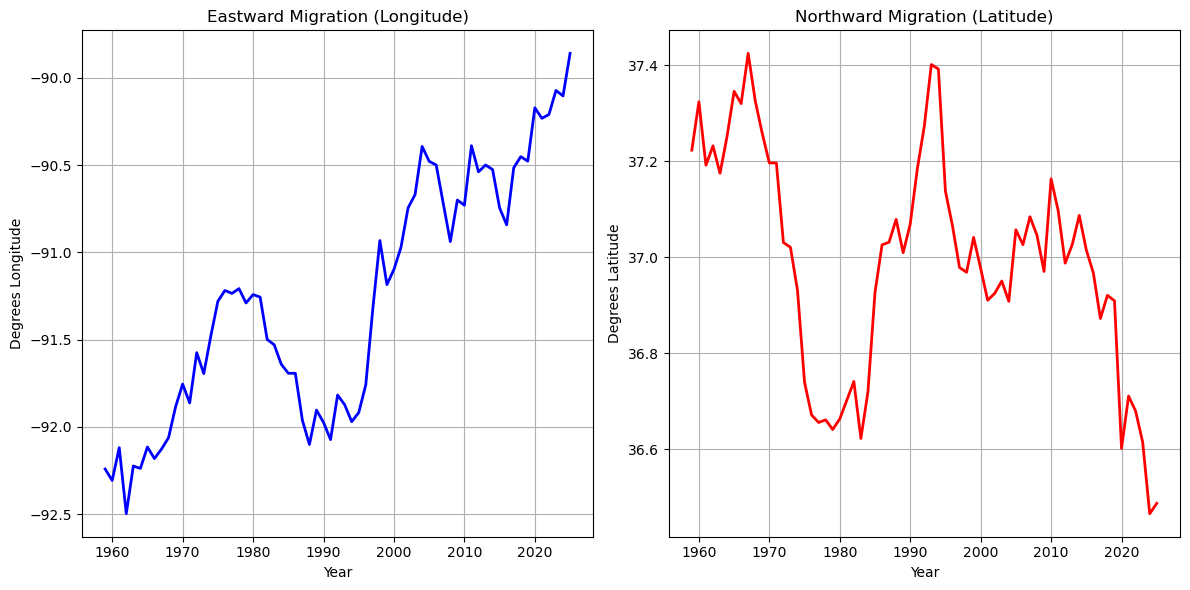

In [22]:
# 1. Calculate the annual centroid (mean Lat/Lon)
centroids = df.groupby('YEAR')[['BEGIN_LAT', 'BEGIN_LON']].mean().reset_index()

# 2. Add a rolling average to smooth out the "noise" of individual years
centroids['lat_rolling'] = centroids['BEGIN_LAT'].rolling(window=10).mean()
centroids['lon_rolling'] = centroids['BEGIN_LON'].rolling(window=10).mean()

# 3. Simple Plotting to visualize the "Great Migration"
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plotting the Longitude shift (East/West)
plt.subplot(1, 2, 1)
plt.plot(centroids['YEAR'], centroids['lon_rolling'], color='blue', linewidth=2)
plt.title('Eastward Migration (Longitude)')
plt.xlabel('Year')
plt.ylabel('Degrees Longitude')
plt.grid(True)

# Plotting the Latitude shift (North/South)
plt.subplot(1, 2, 2)
plt.plot(centroids['YEAR'], centroids['lat_rolling'], color='red', linewidth=2)
plt.title('Northward Migration (Latitude)')
plt.xlabel('Year')
plt.ylabel('Degrees Latitude')
plt.grid(True)

plt.tight_layout()
plt.show()

In [18]:
import pymannkendall as mk

# 1. Prepare the data
data_lon = centroids['lon_rolling'].dropna()
data_lat = centroids['lat_rolling'].dropna()

# 2. Run the test for the Eastward shift
res_lon = mk.original_test(data_lon)
print("--- Longitude (Eastward) Trend Analysis ---")
print(f"Trend: {res_lon.trend}")
print(f"P-Value: {res_lon.p:.5f}")
# Using .slope or .s if .tau is missing
print(f"Sen's Slope (Magnitude): {res_lon.slope:.5f}") 

# 3. Run the test for the Northward shift
res_lat = mk.original_test(data_lat)
print("\n--- Latitude (Northward) Trend Analysis ---")
print(f"Trend: {res_lat.trend}")
print(f"P-Value: {res_lat.p:.5f}")
print(f"Sen's Slope (Magnitude): {res_lat.slope:.5f}")

--- Longitude (Eastward) Trend Analysis ---
Trend: increasing
P-Value: 0.00000
Sen's Slope (Magnitude): 0.03200

--- Latitude (Northward) Trend Analysis ---
Trend: decreasing
P-Value: 0.00015
Sen's Slope (Magnitude): -0.00536


In [19]:
# 1. Convert to datetime and calculate Local Solar Hour
df['BEGIN_DATE_TIME'] = pd.to_datetime(df['BEGIN_DATE_TIME'], format='mixed')

# 2. Drop any rows where longitude is missing BEFORE the calculation
df = df.dropna(subset=['BEGIN_LON'])

# 3. Calculate Local Solar Hour
df['local_solar_hour'] = (df['BEGIN_DATE_TIME'].dt.hour + (df['BEGIN_LON'] / 15)) % 24

# 4. Re-split the eras
era1 = df[df['YEAR'] <= 1985]
era2 = df[df['YEAR'] >= 1990]

print(f"Cleaned data: {len(df)} rows remain for analysis.")

# Now the get_polar_data function won't hit any NaNs
def get_polar_data(data):
    counts = data.groupby(data['local_solar_hour'].astype(int)).size()
    counts = counts.reindex(range(24), fill_value=0)
    return counts / counts.sum()

# Run your Plotting code here...

Cleaned data: 42798 rows remain for analysis.


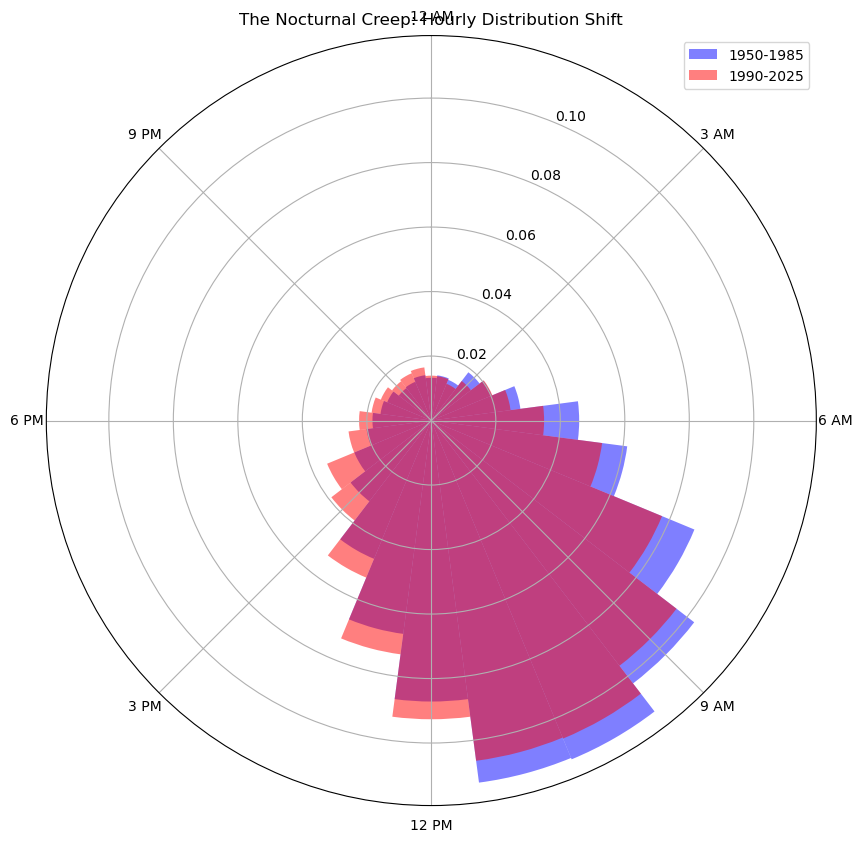

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Split the data into two eras
era1 = df[df['YEAR'] <= 1985]
era2 = df[df['YEAR'] >= 1990]

def get_polar_data(data):
    # Group by the local solar hour we calculated earlier
    counts = data.groupby(data['local_solar_hour'].astype(int)).size()
    # Ensure all 24 hours are represented
    counts = counts.reindex(range(24), fill_value=0)
    # Convert to proportions for fair comparison
    return counts / counts.sum()

# 2. Setup the Polar Plot
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': 'polar'})

theta = np.linspace(0, 2*np.pi, 24, endpoint=False)
width = (2*np.pi) / 24

# Plot Era 1 (Traditional)
ax.bar(theta, get_polar_data(era1), width=width, alpha=0.5, label='1950-1985', color='blue')

# Plot Era 2 (Modern)
ax.bar(theta, get_polar_data(era2), width=width, alpha=0.5, label='1990-2025', color='red')

# Formatting the "Clock"
ax.set_theta_zero_location('N') # 12 AM at the top
ax.set_theta_direction(-1)      # Clockwise
ax.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax.set_xticklabels(['12 AM', '3 AM', '6 AM', '9 AM', '12 PM', '3 PM', '6 PM', '9 PM'])
plt.legend(loc='upper right')
plt.title("The Nocturnal Creep: Hourly Distribution Shift", va='bottom')
# The 'bbox_inches' parameter ensures no labels are cut off
plt.savefig('../visual_outputs/nocturnal_creep_clock_plot.png', dpi=300, bbox_inches='tight')
plt.show()

Fetching US map data...


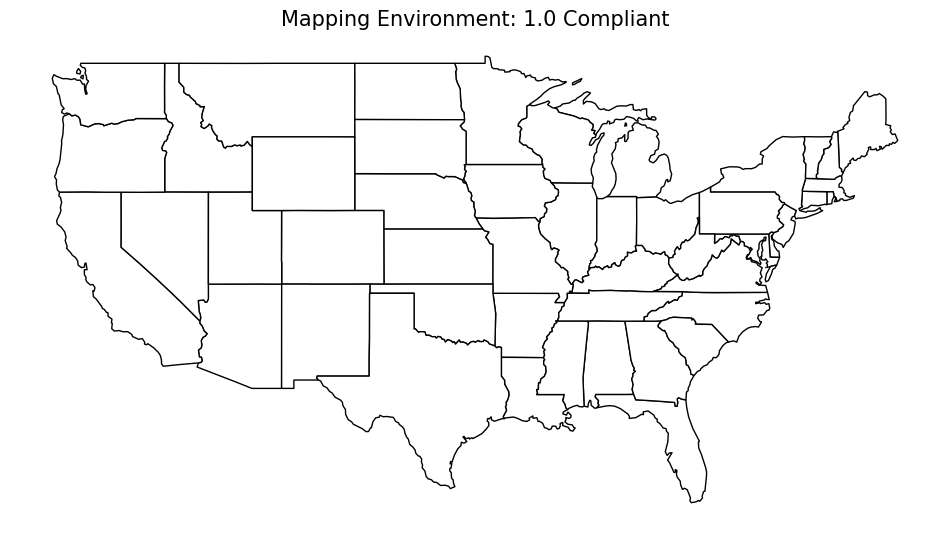

In [26]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Use a direct URL to a standard US States GeoJSON
# This is more robust than the old internal datasets
usa_url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"

print("Fetching US map data...")

try:
    # 2. Load the data directly from the URL
    usa = gpd.read_file(usa_url)
    
    # 3. Filter out Alaska and Hawaii for a better view of 'Tornado Alley'
    # These coordinates are roughly for the Contiguous US
    usa = usa[~usa['name'].isin(['Alaska', 'Hawaii', 'Puerto Rico'])]

    # 4. Plot the result
    fig, ax = plt.subplots(figsize=(12, 8))
    usa.plot(ax=ax, color='white', edgecolor='black')
    
    ax.set_title("Mapping Environment: 1.0 Compliant", fontsize=15)
    ax.axis('off') # Cleaner look for a portfolio
    plt.show()

except Exception as e:
    print(f"Connection issue: {e}")

In [27]:
from shapely.geometry import Point

# 1. Convert the standard DataFrame into a GeoDataFrame
# WGS84 (EPSG:4326) is the standard 'GPS' coordinate system
gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df.BEGIN_LON, df.BEGIN_LAT),
    crs="EPSG:4326"
)

# 2. Ensure the USA map and Tornado points are in the same coordinate system
usa = usa.to_crs(gdf.crs)

print("Conversion to GeoDataFrame complete. Points are now spatially aware.")

Conversion to GeoDataFrame complete. Points are now spatially aware.


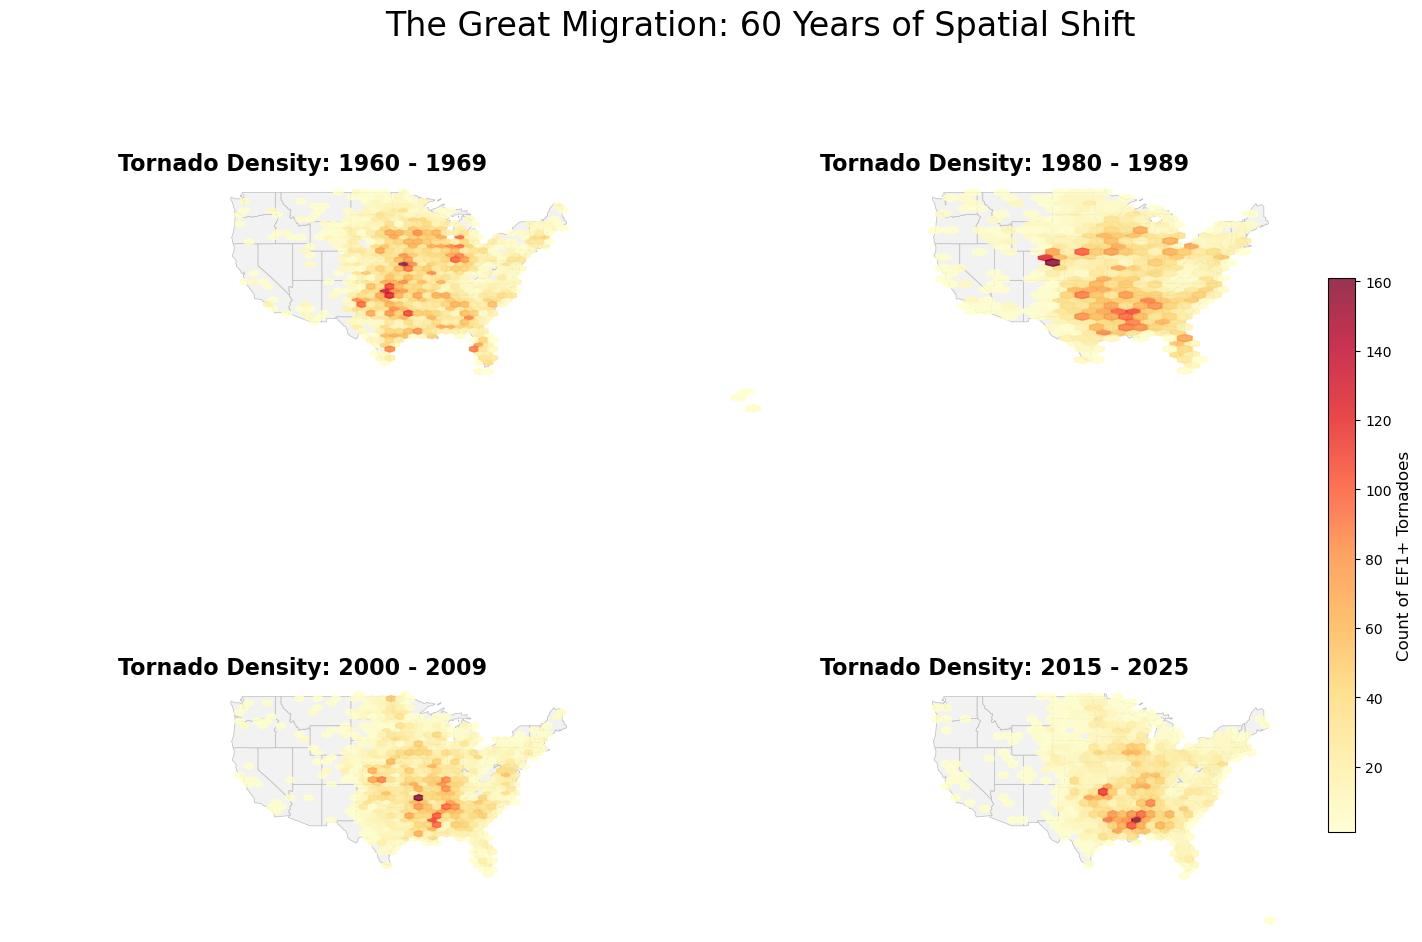

In [28]:
import matplotlib.pyplot as plt

# 1. Define our four focus decades
decades = [1960, 1980, 2000, 2015]
fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, start_year in enumerate(decades):
    ax = axes[i]
    
    # Filter for the 10-year window (using 2015-present for the last one)
    end_year = start_year + 9 if start_year < 2015 else 2025
    decade_df = gdf[(gdf['YEAR'] >= start_year) & (gdf['YEAR'] <= end_year)]
    
    # Draw the US base map
    usa.plot(ax=ax, color='#f2f2f2', edgecolor='#bcbcbc', linewidth=0.5)
    
    # Create the Heatmap (Hexbins)
    # 'gridsize' controls the resolution of the hexagons
    hb = ax.hexbin(
        decade_df.geometry.x, 
        decade_df.geometry.y, 
        gridsize=35, 
        cmap='YlOrRd', 
        mincnt=1, 
        alpha=0.8
    )
    
    ax.set_title(f"Tornado Density: {start_year} - {end_year}", fontsize=16, fontweight='bold')
    ax.axis('off')

# 2. Add a colorbar to explain the density
cb = fig.colorbar(hb, ax=axes.tolist(), shrink=0.6, location='right', pad=0.02)
cb.set_label('Count of EF1+ Tornadoes', fontsize=12)

plt.suptitle("The Great Migration: 60 Years of Spatial Shift", fontsize=24, y=0.95)

# 3. Save it to your outputs folder
plt.savefig('../visual_outputs/decadal_migration_heatmaps.png', dpi=300, bbox_inches='tight')

plt.show()